# external data - macro

In [1]:
!pip install yfinance pandas-datareader -q

In [2]:
pip install --upgrade yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import polars as pl
import warnings
from datetime import date


In [4]:
(
    pl.scan_parquet('../data/raw/bitcoin_analytics.parquet')
    .filter(
        (pl.col("date") >= date(2018, 1, 1)) & 
        (pl.col("date") <= date(2023, 12, 31))
    )
    .sink_parquet('../data/processed/bitcoin_analytics_train.parquet')
)
print("Filtering complete. Saved to bitcoin_analytics_filter.parquet")


Filtering complete. Saved to bitcoin_analytics_filter.parquet


In [5]:
(
    pl.scan_parquet('../data/raw/bitcoin_analytics.parquet')
    .filter(
        (pl.col("date") >= date(2018, 1, 1)) & 
        (pl.col("date") <= date(2025, 12, 31))
    )
    .sink_parquet('../data/processed/bitcoin_analytics_full_2025.parquet')
)
print("Filtering complete. Saved to bitcoin_analytics_full_2025.parquet")


Filtering complete. Saved to bitcoin_analytics_full_2025.parquet


In [8]:
url = "https://drive.google.com/uc?export=download&id=1SyWrXetOSO37xvV7UWlHI9UZ1447Rzxv"

enriched_bitcoin_analytics_full_2025 = pd.read_parquet(url)
enriched_bitcoin_analytics_full_2025.to_parquet('../data/processed/enriched_bitcoin_analytics_full_2025.parquet')

In [9]:
(
    pl.scan_parquet('../data/processed/enriched_bitcoin_analytics_full_2025.parquet')
    .filter(
        (pl.col("date") >= date(2018, 1, 1)) & 
        (pl.col("date") <= date(2023, 12, 31))
    )
    .sink_parquet('../data/processed/enriched_btc_df_train.parquet')
)
print("Filtering complete. Saved to enriched_btc_df_train.parquet")


Filtering complete. Saved to enriched_btc_df_train.parquet


In [12]:
enriched_btc_df = pd.read_parquet("../data/processed/enriched_btc_df_train.parquet")

# 4 strat -> which one applied first choose it and ignored the rest

In [ ]:
import polars as pl
from stacksats import StrategyRunner, BacktestConfig
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation
import stacksats.strategy_types._legacy 

enriched_btc_df = pl.from_pandas(enriched_btc_df).with_columns(pl.col('date').cast(pl.Datetime))

# ---------------------------------------------------------
# 0. Turn off the 3 safety rails
# ---------------------------------------------------------
patch_val = 0.0
stacksats.framework_contract.MIN_DAILY_WEIGHT = patch_val
stacksats.runner.validation.MIN_DAILY_WEIGHT = patch_val
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT = patch_val

# ---------------------------------------------------------
# 1. Feature Engineering (Macro Variables)
# ---------------------------------------------------------
# Calculate the 90-day percentage change in Treasury Yields -> 90-day because its = 1 financial quarter of 3 months
if 'Treasury_90d_Delta' not in enriched_btc_df.columns:
    enriched_btc_df = enriched_btc_df.with_columns(
        ((pl.col('Treasury_10Y') / pl.col('Treasury_10Y').shift(90)) - 1).alias('Treasury_90d_Delta')
    )

# ---------------------------------------------------------
# 2. The Master Multi-Factor Strategy
# ---------------------------------------------------------
class TunableMasterStrategy(BaseStrategy):
    def __init__(self, macro_spike, mom_break, boost, dampen):
        self.macro_spike = macro_spike
        self.mom_break = mom_break
        self.boost = boost
        self.dampen = dampen
        
        # Dynamic cache-busting ID
        self.strategy_id = f"master_{macro_spike}_{mom_break}_{boost}_{dampen}"
        self.version = "1.0.0"

    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        # Pull the global macro data we just created
        global enriched_btc_df
        macro_subset = enriched_btc_df.select(['date', 'Treasury_90d_Delta', 'MOM15', 'price_usd'])
        
        base_scores = compute_preference_scores(features_df=features_df, start_date=ctx.start_date, end_date=ctx.end_date)
        merged = base_scores.join(macro_subset, on='date', how='inner')
        
        # We need the 1-year lookback for YOUR Value-Floor Strategy
        merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
        
        # --- THE MASTER RULES ---
        # 1. MACRO CRASH (Fed Tightening + Momentum Dying)
        condition_macro_crash = (
            (pl.col('Treasury_90d_Delta') >= self.macro_spike) & 
            (pl.col('MOM15') <= self.mom_break)
        )
        
        # 2. YOUR VALUE CRASH (Price down 60% from last year)
        condition_value_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.4)
        
        # 3. GOLDEN CROSS (Fed Easing + Momentum Rising)
        condition_golden = (
            (pl.col('Treasury_90d_Delta') <= 0.0) & 
            (pl.col('MOM15') >= 0.0)
        )
                
        merged = merged.with_columns(
            pl.when(condition_value_crash)
            .then(
                # TIER 1: Normal market crash. Buy the blood! (Takes absolute priority)
                pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.6)) 
            )
            .when(condition_macro_crash)
            .then(
                # TIER 2: Fed is draining liquidity. DO NOT BUY! Hoard cash!
                pl.lit(0.00001) 
            )
            .when(condition_golden)
            .then(
                # TIER 3: Macro environment is perfect. Boost the MVRV!
                pl.max_horizontal(pl.col('preference') * self.boost, pl.lit(0.4))
            )
            .otherwise(
                # NORMAL MARKET: Dampen MVRV to save cash.
                pl.max_horizontal(pl.col('preference') * self.dampen, pl.lit(0.00001))
            )
            .alias('value')
        )
        
        # Handle the NaNs from the first 365 days by defaulting to neutral (0.5)
        return merged.select(['date', 'value']).fill_nan(0.5).fill_null(0.5)


### test with train set

In [ ]:
from stacksats import UniformStrategy, MVRVStrategy, ExportConfig

# ---------------------------------------------------------
# 2. Setup the Data and Runner
# ---------------------------------------------------------
runner = StrategyRunner()

# ---------------------------------------------------------
# 3. Calculate Score and Win Rate (Backtest tool)
# ---------------------------------------------------------
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

print("Running New Master Macro Strategy (2018-2023)...")

# We pick one combination to test manually!
master_strat = TunableMasterStrategy(macro_spike=0.30, mom_break=-0.05, boost=3.0, dampen=0.2)

# Notice we use `enriched_btc_df` so the Macro data is included!
macro_result = runner.backtest(master_strat, config)
uni_result = runner.backtest(UniformStrategy(), config)
mvrv_result = runner.backtest(MVRVStrategy(), config)

print(f"-> Master Macro Score: {macro_result.score:.2f}")
print(f"-> Master Macro Win Rate: {macro_result.win_rate:.1f}%")
print(f"-> Master Macro Exponential decay percentile: {macro_result.exp_decay_percentile:.1f}%")

print(f"-> MVRV Score: {mvrv_result.score:.2f}")
print(f"-> MVRV Win Rate: {mvrv_result.win_rate:.1f}%")
print(f"-> MVRV Exponential decay percentile: {mvrv_result.exp_decay_percentile:.1f}%")

print(f"-> Uniform Score: {uni_result.score:.2f}")
print(f"-> Uniform Win Rate: {uni_result.win_rate:.1f}%")

print("-" * 40)
# ---------------------------------------------------------
# 4. Calculate Exact Sats Accumulated (Export tool)
# ---------------------------------------------------------
macro_dynamic = []
mvrv_list = []
baseline_list = []

print("Calculating Total Sats Accumulated...")

for year in range(2018, 2024):
    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # Export all 3 strategies!
    dyn = runner.export(master_strat, export_config).to_dataframe()
    mvrv = runner.export(MVRVStrategy(), export_config).to_dataframe()
    base = runner.export(UniformStrategy(), export_config).to_dataframe()
    
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    mvrv_flat = mvrv.group_by('date').agg([
        pl.col('weight').mean().alias('mvrv_weight')
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    mvrv_list.append(mvrv_flat)
    baseline_list.append(base_flat)

# Combine the 6 years
dynamic_weights = pl.concat(macro_dynamic)
mvrv_weights = pl.concat(mvrv_list)
baseline_weights = pl.concat(baseline_list)

# Join them all into one massive table
merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')
merged_sats = merged_sats.join(mvrv_weights, on='date', how='inner')

# Calculate the daily sats accumulated for all 3
merged_sats = merged_sats.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

total_macro_sats = merged_sats["sats_accumulated_dynamic"].sum()
total_mvrv_sats = merged_sats["sats_accumulated_mvrv"].sum()
total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

print(f"Total Sats (Master Macro Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats (MVRV Strategy): {total_mvrv_sats:,.0f} Sats")
print(f"Total Sats (Uniform DCA): {total_base_sats:,.0f} Sats")

Running New Master Macro Strategy (2018-2023)...
-> Master Macro Score: 37.08
-> Master Macro Win Rate: 66.3%
-> Master Macro Exponential decay percentile: 7.8%
-> MVRV Score: 23.53
-> MVRV Win Rate: 41.9%
-> MVRV Exponential decay percentile: 5.2%
-> Uniform Score: 18.65
-> Uniform Win Rate: 0.0%
----------------------------------------
Calculating Total Sats Accumulated...
Total Sats (Master Macro Strategy): 47,736 Sats
Total Sats (MVRV Strategy): 47,797 Sats
Total Sats (Uniform DCA): 50,551 Sats


In [ ]:
# 1. Add Year and Month columns
merged_sats = merged_sats.with_columns([
    pl.col('date').dt.year().alias('year'),
    pl.col('date').dt.month().alias('month')
])
# 2. Group by Year and Month, and sum the Sats!
monthly_sums = merged_sats.group_by(['year', 'month']).agg([
    pl.col('sats_accumulated_dynamic').sum().round(0).alias('Master_Macro_Sats'),
    pl.col('sats_accumulated_baseline').sum().round(0).alias('Baseline_Sats'),
    pl.col('sats_accumulated_mvrv').sum().round(0).alias('Factory_MVRV_Sats')
]).sort(['year', 'month'])
# 3. Calculate exactly how many Sats we won/lost vs the Baseline
monthly_sums = monthly_sums.with_columns(
    (pl.col('Master_Macro_Sats') - pl.col('Baseline_Sats')).alias('Macro_vs_Baseline_Diff')
)
monthly_sums

year,month,Master_Macro_Sats,Baseline_Sats,Factory_MVRV_Sats,Macro_vs_Baseline_Diff
i32,i8,f64,f64,f64,f64
2018,1,1049.0,674.0,2507.0,375.0
2018,2,1489.0,829.0,3213.0,660.0
2018,3,1717.0,963.0,4137.0,754.0
2018,4,1131.0,1040.0,1778.0,91.0
2018,5,1183.0,1018.0,0.0,165.0
…,…,…,…,…,…
2023,8,0.0,306.0,1.0,-306.0
2023,9,0.0,313.0,3.0,-313.0
2023,10,0.0,288.0,1.0,-288.0


In [ ]:
decembers_only = monthly_sums.filter(pl.col('month') == 4)
decembers_only

year,month,Master_Macro_Sats,Baseline_Sats,Factory_MVRV_Sats,Macro_vs_Baseline_Diff
i32,i8,f64,f64,f64,f64
2018,4,1131.0,1040.0,1778.0,91.0
2019,4,0.0,1600.0,0.0,-1600.0
2020,4,9.0,1143.0,71.0,-1134.0
2021,4,150.0,145.0,532.0,5.0
2022,4,0.0,199.0,63.0,-199.0
2023,4,0.0,285.0,0.0,-285.0


In [ ]:
# 1. Group strictly by Year and sum the Sats!
yearly_sums = merged_sats.group_by('year').agg([
    pl.col('sats_accumulated_dynamic').sum().round(0).alias('Master_Macro_Sats'),
    pl.col('sats_accumulated_baseline').sum().round(0).alias('Baseline_Sats'),
    pl.col('sats_accumulated_mvrv').sum().round(0).alias('Factory_MVRV_Sats')
]).sort('year')
# 2. Calculate exactly how many Sats we won/lost vs the Baseline
yearly_sums = yearly_sums.with_columns(
    (pl.col('Master_Macro_Sats') - pl.col('Baseline_Sats')).alias('Macro_vs_Baseline_Diff')
)
yearly_sums

year,Master_Macro_Sats,Baseline_Sats,Factory_MVRV_Sats,Macro_vs_Baseline_Diff
i32,f64,f64,f64,f64
2018,13399.0,14736.0,11635.0,-1337.0
2019,15223.0,15921.0,16157.0,-698.0
2020,10267.0,10065.0,12447.0,202.0
2021,2349.0,2206.0,2063.0,143.0
2022,4115.0,4018.0,3109.0,97.0
2023,2382.0,3605.0,2386.0,-1223.0


-> technically in win against macro in 4 years, the total sasts accumulate still lower though -> but win rate is 60%

### graph

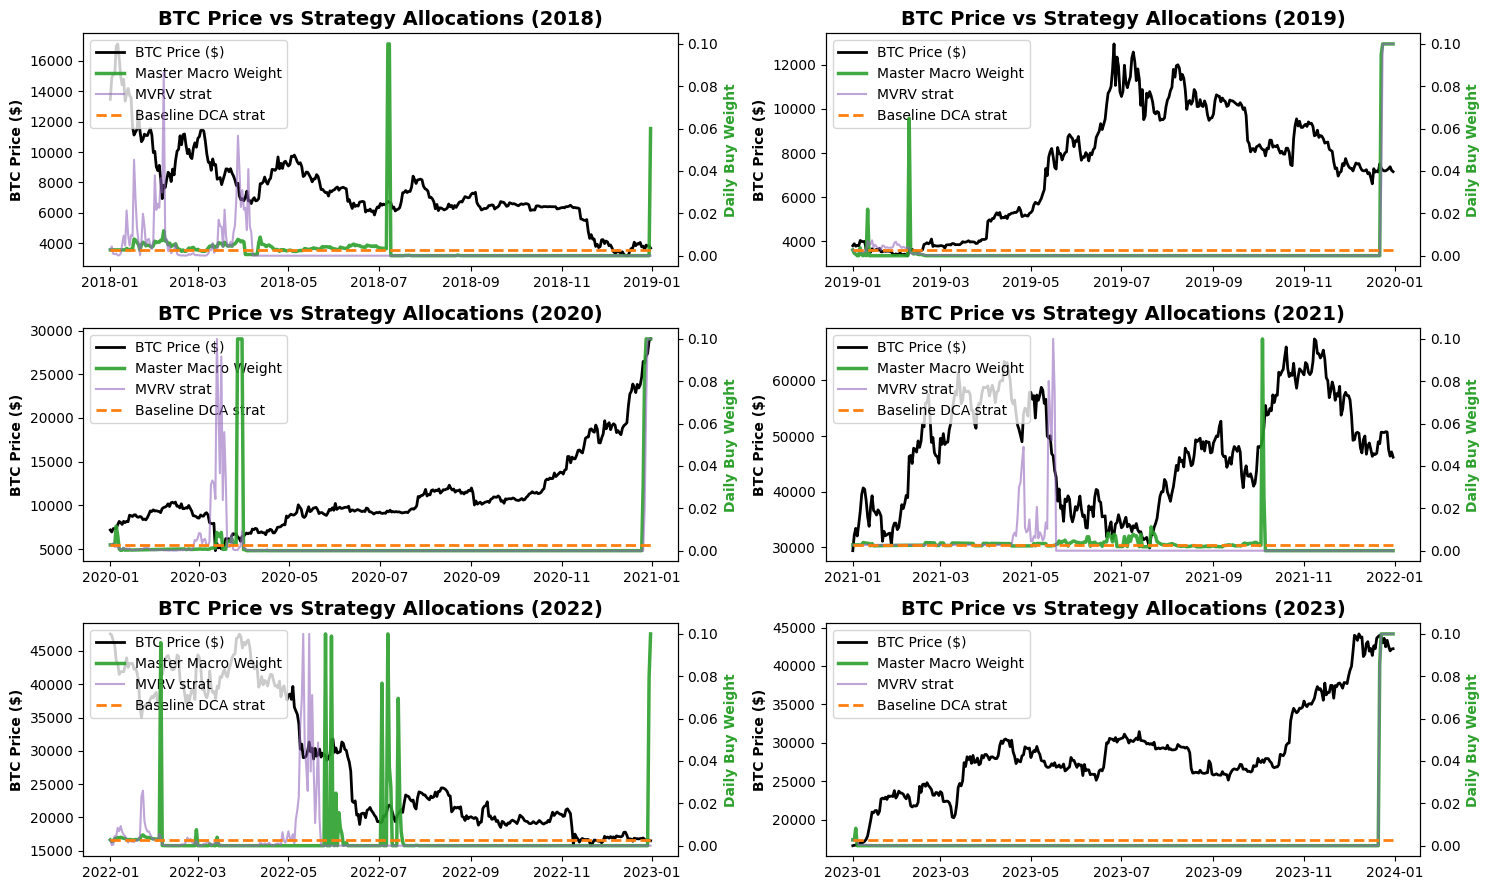

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(15, 9))
axes = axes.flatten()

for i, year in enumerate(range(2018, 2024)):
    year_data = merged_sats.filter(pl.col('year') == year).sort('date')
    
    ax1 = axes[i]
    # Create the twin axis for the weights
    ax2 = ax1.twinx()
    
    # 1. Plot the Bitcoin Price on the Left Axis (Black Line)
    ax1.plot(year_data['date'], year_data['price_usd'], color='black', linewidth=2, label='BTC Price ($)')
    
    # 2. Plot the Strategy Weights on the Right Axis
    ax2.plot(year_data['date'], year_data['dynamic_weight'], color='tab:green', label='Master Macro Weight', linewidth=2.5, alpha=0.9)
    ax2.plot(year_data['date'], year_data['mvrv_weight'], color='tab:purple', label='MVRV strat', linewidth=1.5, alpha=0.6)
    ax2.plot(year_data['date'], year_data['baseline_weight'], color='tab:orange', label='Baseline DCA strat', linestyle='--', linewidth=2)
    
    ax1.set_title(f'BTC Price vs Strategy Allocations ({year})', fontsize=14, fontweight='bold')
    ax1.set_ylabel('BTC Price ($)', color='black', fontweight='bold')
    ax2.set_ylabel('Daily Buy Weight', color='tab:green', fontweight='bold')
    
    # Combine the legends from both axes so they look clean
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

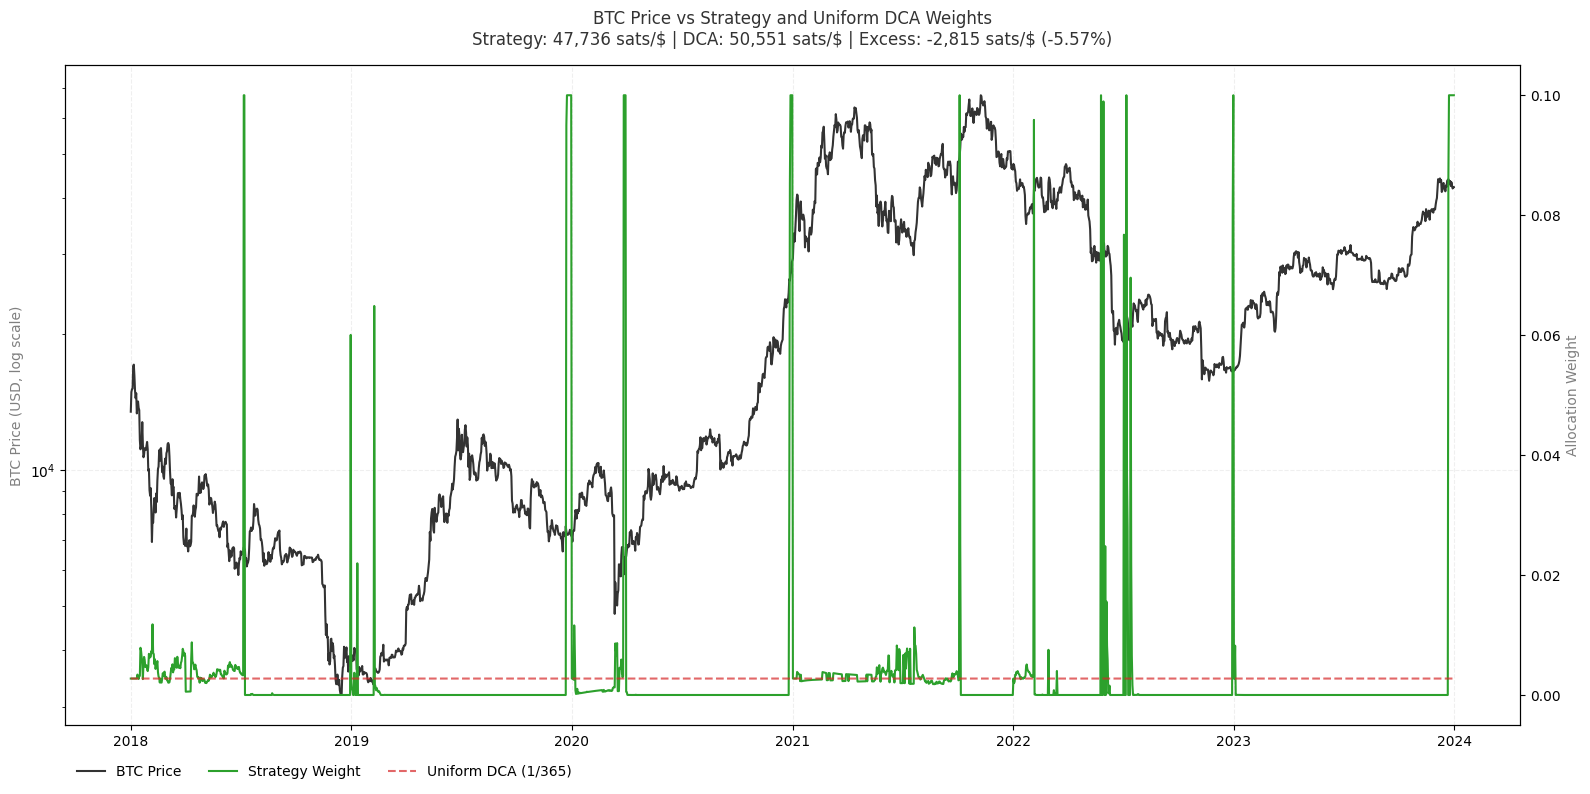

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import datetime

# 1. Sort the data perfectly by date to prevent criss-crossing
merged_sats = merged_sats.sort('date')

# 2. Calculate Sats for the entire dataset
strat_sats = merged_sats['sats_accumulated_dynamic'].sum()
base_sats = merged_sats['sats_accumulated_baseline'].sum()
diff = strat_sats - base_sats
pct = (diff / base_sats) * 100 if base_sats > 0 else 0

# Create the beautiful, single-line Title Text
title_text = (
    "BTC Price vs Strategy and Uniform DCA Weights\n"
    f"Strategy: {strat_sats:,.0f} sats/$ | DCA: {base_sats:,.0f} sats/$ | "
    f"Excess: {'+' if diff > 0 else ''}{diff:,.0f} sats/$ ({'+' if pct > 0 else ''}{pct:.2f}%)"
)

# 3. Create the Plot
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Plot Price on Left Axis (LOG SCALE)
ax1.plot(merged_sats['date'], merged_sats['price_usd'], color='black', linewidth=1.5, label='BTC Price', alpha=0.8)
ax1.set_yscale('log')
ax1.set_ylabel('BTC Price (USD, log scale)', color='gray')

# Plot Weights on Right Axis (LINEAR SCALE)
ax2.plot(merged_sats['date'], merged_sats['dynamic_weight'], color='tab:green', linewidth=1.5, label='Strategy Weight')
ax2.plot(merged_sats['date'], merged_sats['baseline_weight'], color='tab:red', linestyle='--', linewidth=1.5, label='Uniform DCA (1/365)', alpha=0.7)
ax2.set_ylabel('Allocation Weight', color='gray')

# Formatting
plt.title(title_text, fontsize=12, pad=15, color='#333333')
ax1.grid(True, alpha=0.2, linestyle='--')

# Combine Legends at the bottom
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', frameon=False, ncol=3, bbox_to_anchor=(0, -0.1))

plt.tight_layout()
plt.show()


### math

This is the absolute core of your Capstone project! You need to be able to explain this math clearly to your professors. 

Think of this code as a **4-Tier Mathematical Hierarchy**. The algorithm checks the rules in order from top to bottom. As soon as one rule is True, it executes the math and skips the rest.

Here is exactly how the math works for each rule:

### 1. The Triggers (The Inputs)
Before making a decision, the algorithm calculates three metrics:
* **`Treasury_90d_Delta`**: Calculates the percentage change in the 10-Year Treasury Yield over 90 days. `(Today / 90_days_ago) - 1`. If the yield goes from 2.0% to 2.6%, the delta is `0.30` (a 30% spike).
* **`MOM15`**: Calculates Bitcoin's 15-day price momentum.
* **`price_1y_ago`**: Looks at the exact price of Bitcoin 365 days ago.

### 2. The 4-Tier Logic Hierarchy (The Multipliers)
Every single day, the algorithm evaluates these tiers in order:

**Tier 1: The Macro Veto (The Panic Button)**
* **The Math:** If `Treasury_90d_Delta >= 0.30` AND `MOM15 <= -0.05`.
* **The Action:** Output `0.00001`. 
* **Explanation:** The Federal Reserve is aggressively attacking the economy, and Bitcoin is already bleeding. The algorithm overrides everything else and sets the buy weight to essentially zero. It hoards cash.

**Tier 2: The Value Crash (The Mega-Buy)**
* **The Math:** If `price_usd <= (price_1y_ago * 0.4)`. 
* **The Action:** `max_horizontal(preference * 2.0, 0.6)`. 
* **Explanation:** If Bitcoin has dropped 60% from last year, there is massive blood in the streets. It takes the normal MVRV score (`preference`), multiplies it by 2, and guarantees it will *never* drop below a massive `0.6` floor. It buys with both hands.

**Tier 3: The Golden Cross (The Bull Market)**
* **The Math:** If `Treasury_90d_Delta <= 0` (rates are dropping) AND `MOM15 >= 0` (trend is up).
* **The Action:** `max_horizontal(preference * 3.0, 0.4)`.
* **Explanation:** Liquidity is flowing into the market, and the trend is your friend. It triples the MVRV score and guarantees a solid `0.4` floor.

**Tier 4: The Normal Market (The Piggy Bank)**
* **The Math:** If nothing exciting is happening.
* **The Action:** `max_horizontal(preference * 0.2, 0.00001)`.
* **Explanation:** It takes the normal MVRV score and slashes it by 80% (`* 0.2`). It is intentionally "cheap" during boring markets so it can build up a massive pile of cash for the next crash.

### 3. The Normalization Engine (The Hidden Math)
The most important thing to know is that `0.6` or `0.00001` are **NOT** the actual dollar amounts spent! 

The framework takes all of these raw scores and mathematically **normalizes** them across a rolling 365-day window so that they always sum to $365 a year. 
Because Tier 4 (`0.00001`) artificially suppresses the math for months at a time, it builds up massive "stored budget". When Tier 2 (`0.6`) finally triggers, the normalization math acts like a dam breaking, unleashing all of that stored cash into the market in a massive geyser!

### grid search - hyperparameter optimization

In [ ]:
# # ---------------------------------------------------------
# # 3. The Grid Search
# # ---------------------------------------------------------
# runner = StrategyRunner()
# config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

# # The ranges we want to test!
# macro_spikes  = [0.10, 0.20, 0.30]   # Try 10%, 20%, 30% spikes in Treasury yields
# mom_breaks    = [-0.05, 0.0, 0.05]   # Momentum thresholds
# boosts        = [2.0, 3.0]           # How much to buy during Golden Cross
# dampens       = [0.1, 0.2]           # How much to hoard during normal markets

# leaderboard = []

# print(f"Starting Macro Grid Search. Testing {len(macro_spikes) * len(mom_breaks) * len(boosts) * len(dampens)} combinations...")

# for ms in macro_spikes:
#     for mb in mom_breaks:
#         for b in boosts:
#             for d in dampens:
                
#                 strat = TunableMasterStrategy(macro_spike=ms, mom_break=mb, boost=b, dampen=d)
#                 result = runner.backtest(strat, config, btc_df=enriched_btc_df)
                
#                 leaderboard.append({
#                     "Macro_Spike": ms,
#                     "Mom_Break": mb,
#                     "Boost": b,
#                     "Dampen": d,
#                     "Score": float(result.score),
#                     "Win_Rate": float(result.win_rate)
#                 })

# results_df = pl.DataFrame(leaderboard).sort("Win_Rate", descending=True)

# print("\n🏆 HYPERPARAMETER GRID SEARCH WINNERS 🏆")
# display(results_df.head(10))

Starting Macro Grid Search. Testing 36 combinations...

🏆 HYPERPARAMETER GRID SEARCH WINNERS 🏆


Macro_Spike,Mom_Break,Boost,Dampen,Score,Win_Rate
f64,f64,f64,f64,f64,f64
0.3,-0.05,3.0,0.2,34.017308,60.207991
0.2,-0.05,3.0,0.2,33.415228,59.003831
0.3,0.0,3.0,0.2,32.889053,57.909141
0.3,-0.05,2.0,0.2,32.779829,57.525999
0.2,-0.05,2.0,0.2,32.642992,57.252326
0.3,0.0,2.0,0.2,32.664166,57.252326
0.1,-0.05,3.0,0.2,32.347904,56.869184
0.1,-0.05,2.0,0.2,32.232483,56.431308
0.3,0.05,3.0,0.2,32.209894,56.267105


In [ ]:
import polars as pl

# The parameter ranges
macro_spikes  = [0.10, 0.20, 0.30]   
mom_breaks    = [-0.05, 0.0, 0.05]   
boosts        = [2.0, 3.0]           
dampens       = [0.1, 0.2]           

leaderboard = []

print(f"Starting Multi-Objective Grid Search (Win Rate + Total Sats)...")
print("This calculates 216 individual years of data. It will take ~2 minutes. Grab a coffee!")

for ms in macro_spikes:
    for mb in mom_breaks:
        for b in boosts:
            for d in dampens:
                
                strat = TunableMasterStrategy(macro_spike=ms, mom_break=mb, boost=b, dampen=d)
                
                # 1. Get the Win Rate Consistency (Backtest Engine)
                result = runner.backtest(strat, config, btc_df=enriched_btc_df)
                win_rate = float(result.win_rate)
                
                # 2. Get the Absolute Profit (Export Engine)
                macro_dynamic = []
                for year in range(2018, 2024):
                    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
                    dyn = runner.export(strat, export_config, btc_df=enriched_btc_df).to_dataframe()
                    
                    dyn_flat = dyn.group_by('date').agg([
                        pl.col('weight').mean().alias('dynamic_weight'),
                        pl.col('price_usd').first()
                    ])
                    macro_dynamic.append(dyn_flat)
                
                dynamic_weights = pl.concat(macro_dynamic)
                
                # Calculate the raw Sats
                total_sats = (dynamic_weights['dynamic_weight'] / dynamic_weights['price_usd'] * 100_000_000).sum()
                
                # Save both metrics!
                leaderboard.append({
                    "Macro_Spike": ms,
                    "Mom_Break": mb,
                    "Boost": b,
                    "Dampen": d,
                    "Win_Rate": win_rate,
                    "Total_Sats": total_sats
                })

# Convert to DataFrame
results_df = pl.DataFrame(leaderboard)

# THE HOLY GRAIL FILTER: 
# 1. Must have > 50% Win Rate (Consistent Risk-Adjustment)
# 2. Must beat the Baseline DCA of 50,551 Sats (Profitable Absolute Return)
holy_grail_df = results_df.filter(
    (pl.col("Win_Rate") > 50.0) & 
    (pl.col("Total_Sats") > 50551)
).sort("Total_Sats", descending=True)

print("\n🏆 THE HOLY GRAIL WINNERS (High Consistency + High Profit) 🏆")
display(holy_grail_df)

print("\n📊 ALL RESULTS (Sorted by Total Sats) 📊")
display(results_df.sort("Total_Sats", descending=True).head(10))


Starting Multi-Objective Grid Search (Win Rate + Total Sats)...
This calculates 216 individual years of data. It will take ~2 minutes. Grab a coffee!

🏆 THE HOLY GRAIL WINNERS (High Consistency + High Profit) 🏆


Macro_Spike,Mom_Break,Boost,Dampen,Win_Rate,Total_Sats
f64,f64,f64,f64,f64,f64



📊 ALL RESULTS (Sorted by Total Sats) 📊


Macro_Spike,Mom_Break,Boost,Dampen,Win_Rate,Total_Sats
f64,f64,f64,f64,f64,f64
0.3,-0.05,2.0,0.2,57.525999,49820.476781
0.3,0.0,2.0,0.2,57.252326,49804.272378
0.3,0.05,2.0,0.2,55.446086,49802.867348
0.2,-0.05,2.0,0.2,57.252326,49796.579785
0.2,0.0,2.0,0.2,53.256705,49768.730035
0.2,0.05,2.0,0.2,49.534756,49761.052926
0.1,-0.05,2.0,0.2,56.431308,49631.566967
0.1,0.0,2.0,0.2,49.589491,49600.232664
0.1,0.05,2.0,0.2,46.524357,49559.794141


# weighted 4 strats

In [ ]:
import polars as pl
from stacksats import StrategyRunner, BacktestConfig, ExportConfig

# ---------------------------------------------------------
# 1. The Continuous Linear Factor Strategy
# ---------------------------------------------------------
class LinearFactorStrategy(BaseStrategy):
    def __init__(self, w_mvrv, w_mom, w_macro, w_value):
        self.w_mvrv = w_mvrv
        self.w_mom = w_mom
        self.w_macro = w_macro
        self.w_value = w_value
        
        # Dynamic cache-busting ID
        self.strategy_id = f"linear_{w_mvrv}_{w_mom}_{w_macro}_{w_value}"
        self.version = "1.0.0"

    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        global enriched_btc_df
        macro_subset = enriched_btc_df.select(['date', 'Treasury_90d_Delta', 'MOM15', 'price_usd'])
        
        base_scores = compute_preference_scores(features_df=features_df, start_date=ctx.start_date, end_date=ctx.end_date)
        merged = base_scores.join(macro_subset, on='date', how='inner')
        
        # Calculate the "Value Ratio": If price dropped 60%, this number goes up massively!
        merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
        merged = merged.with_columns(
            (pl.col('price_1y_ago') / pl.col('price_usd')).fill_null(1.0).alias('value_ratio')
        )
        
        # --- THE CONTINUOUS LINEAR ALGEBRA EQUATION ---
        merged = merged.with_columns(
            (
                (pl.col('preference') * self.w_mvrv) + 
                (pl.col('MOM15') * self.w_mom) - 
                (pl.col('Treasury_90d_Delta') * self.w_macro) + 
                (pl.col('value_ratio') * self.w_value)
            ).alias('raw_score')
        )
        
        # Softmax Boundary: Clip the final output so it doesn't break the engine
        merged = merged.with_columns(
            pl.col('raw_score').clip(lower_bound=0.00001, upper_bound=1.0).alias('value')
        )
        
        return merged.select(['date', 'value']).fill_nan(0.5).fill_null(0.5)


In [ ]:
# ---------------------------------------------------------
# 2. Setup the Data and Runner
# ---------------------------------------------------------
runner = StrategyRunner()

# ---------------------------------------------------------
# 3. Calculate Score and Win Rate (Backtest tool)
# ---------------------------------------------------------
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

print("Running New Weighted Master Macro Strategy (2018-2023)...")

# We pick one combination to test manually!
master_strat = LinearFactorStrategy(w_mvrv=0.2, w_mom=0.1, w_macro=0.0, w_value=0.0)

# Notice we use `enriched_btc_df` so the Macro data is included!
macro_result = runner.backtest(master_strat, config)
uni_result = runner.backtest(UniformStrategy(), config)
mvrv_result = runner.backtest(MVRVStrategy(), config)

print(f"-> Weighted Master Macro Score: {macro_result.score:.2f}")
print(f"-> Weighted Master Macro Win Rate: {macro_result.win_rate:.1f}%")
print(f"-> Weighted Master Macro Exponential decay percentile: {macro_result.exp_decay_percentile:.1f}%")

print(f"-> MVRV Score: {mvrv_result.score:.2f}")
print(f"-> MVRV Win Rate: {mvrv_result.win_rate:.1f}%")
print(f"-> MVRV Exponential decay percentile: {mvrv_result.exp_decay_percentile:.1f}%")

print(f"-> Uniform Score: {uni_result.score:.2f}")
print(f"-> Uniform Win Rate: {uni_result.win_rate:.1f}%")

print("-" * 40)
# ---------------------------------------------------------
# 4. Calculate Exact Sats Accumulated (Export tool)
# ---------------------------------------------------------
macro_dynamic = []
mvrv_list = []
baseline_list = []

print("Calculating Total Sats Accumulated...")

for year in range(2018, 2024):
    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # Export all 3 strategies!
    dyn = runner.export(master_strat, export_config).to_dataframe()
    mvrv = runner.export(MVRVStrategy(), export_config).to_dataframe()
    base = runner.export(UniformStrategy(), export_config).to_dataframe()
    
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    mvrv_flat = mvrv.group_by('date').agg([
        pl.col('weight').mean().alias('mvrv_weight')
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    mvrv_list.append(mvrv_flat)
    baseline_list.append(base_flat)

# Combine the 6 years
dynamic_weights = pl.concat(macro_dynamic)
mvrv_weights = pl.concat(mvrv_list)
baseline_weights = pl.concat(baseline_list)

# Join them all into one massive table
merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')
merged_sats = merged_sats.join(mvrv_weights, on='date', how='inner')

# Calculate the daily sats accumulated for all 3
merged_sats = merged_sats.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

total_macro_sats = merged_sats["sats_accumulated_dynamic"].sum()
total_mvrv_sats = merged_sats["sats_accumulated_mvrv"].sum()
total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

print(f"Total Sats (Master Macro Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats (MVRV Strategy): {total_mvrv_sats:,.0f} Sats")
print(f"Total Sats (Uniform DCA): {total_base_sats:,.0f} Sats")

Running New Weighted Master Macro Strategy (2018-2023)...
-> Weighted Master Macro Score: 39.74
-> Weighted Master Macro Win Rate: 49.4%
-> Weighted Master Macro Exponential decay percentile: 30.0%
-> MVRV Score: 23.53
-> MVRV Win Rate: 41.9%
-> MVRV Exponential decay percentile: 5.2%
-> Uniform Score: 18.65
-> Uniform Win Rate: 0.0%
----------------------------------------
Calculating Total Sats Accumulated...
Total Sats (Master Macro Strategy): 49,729 Sats
Total Sats (MVRV Strategy): 47,797 Sats
Total Sats (Uniform DCA): 50,551 Sats


## graph

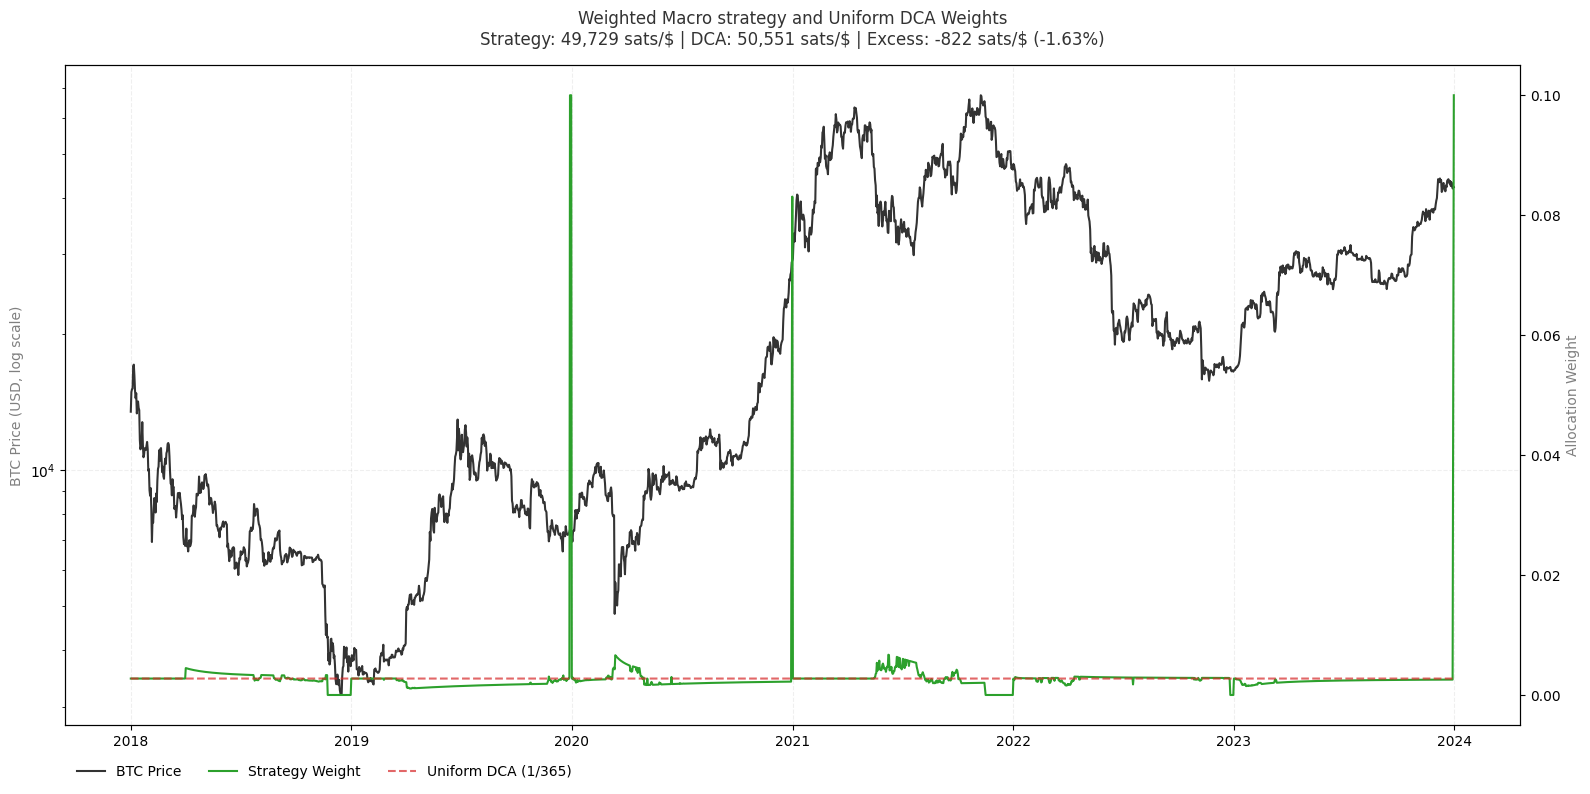

In [ ]:
# 1. Sort the data perfectly by date to prevent criss-crossing
merged_sats = merged_sats.sort('date')

# 2. Calculate Sats for the entire dataset
strat_sats = merged_sats['sats_accumulated_dynamic'].sum()
base_sats = merged_sats['sats_accumulated_baseline'].sum()
diff = strat_sats - base_sats
pct = (diff / base_sats) * 100 if base_sats > 0 else 0

# Create the beautiful, single-line Title Text
title_text = (
    "Weighted Macro strategy and Uniform DCA Weights\n"
    f"Strategy: {strat_sats:,.0f} sats/$ | DCA: {base_sats:,.0f} sats/$ | "
    f"Excess: {'+' if diff > 0 else ''}{diff:,.0f} sats/$ ({'+' if pct > 0 else ''}{pct:.2f}%)"
)

# 3. Create the Plot
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Plot Price on Left Axis (LOG SCALE)
ax1.plot(merged_sats['date'], merged_sats['price_usd'], color='black', linewidth=1.5, label='BTC Price', alpha=0.8)
ax1.set_yscale('log')
ax1.set_ylabel('BTC Price (USD, log scale)', color='gray')

# Plot Weights on Right Axis (LINEAR SCALE)
ax2.plot(merged_sats['date'], merged_sats['dynamic_weight'], color='tab:green', linewidth=1.5, label='Strategy Weight')
ax2.plot(merged_sats['date'], merged_sats['baseline_weight'], color='tab:red', linestyle='--', linewidth=1.5, label='Uniform DCA (1/365)', alpha=0.7)
ax2.set_ylabel('Allocation Weight', color='gray')

# Formatting
plt.title(title_text, fontsize=12, pad=15, color='#333333')
ax1.grid(True, alpha=0.2, linestyle='--')

# Combine Legends at the bottom
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', frameon=False, ncol=3, bbox_to_anchor=(0, -0.1))

plt.tight_layout()
plt.show()


## tuning

In [ ]:

# # ---------------------------------------------------------
# # 2. The Coefficient Grid Search
# # ---------------------------------------------------------
# runner = StrategyRunner()
# config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

# # We are testing the mathematical COEFFICIENTS now, not thresholds!
# w_mvrv_list  = [0.2, 0.5, 1.0]     # Base MVRV weight
# w_mom_list   = [0.0, 0.5, 1.0]     # Momentum weight
# w_macro_list = [0.0, 1.0, 2.0]     # Macro Veto weight (Negative subtraction!)
# w_value_list = [0.0, 0.5, 1.0]     # Value Crash weight

# leaderboard = []

# print(f"Starting Linear Factor Optimization (Win Rate + Total Sats)...")
# print(f"Testing {len(w_mvrv_list) * len(w_mom_list) * len(w_macro_list) * len(w_value_list)} combinations. Give it a few minutes!")

# for w_mvrv in w_mvrv_list:
#     for w_mom in w_mom_list:
#         for w_macro in w_macro_list:
#             for w_value in w_value_list:
                
#                 strat = LinearFactorStrategy(w_mvrv, w_mom, w_macro, w_value)
                
#                 # 1. Win Rate
#                 result = runner.backtest(strat, config)
#                 win_rate = float(result.win_rate)
                
#                 # 2. Total Sats
#                 macro_dynamic = []
#                 for year in range(2018, 2024):
#                     export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
#                     dyn = runner.export(strat, export_config).to_dataframe()
                    
#                     dyn_flat = dyn.group_by('date').agg([
#                         pl.col('weight').mean().alias('dynamic_weight'),
#                         pl.col('price_usd').first()
#                     ])
#                     macro_dynamic.append(dyn_flat)
                
#                 dynamic_weights = pl.concat(macro_dynamic)
#                 total_sats = (dynamic_weights['dynamic_weight'] / dynamic_weights['price_usd'] * 100_000_000).sum()
                
#                 leaderboard.append({
#                     "W_MVRV": w_mvrv,
#                     "W_Mom": w_mom,
#                     "W_Macro": w_macro,
#                     "W_Value": w_value,
#                     "Win_Rate": win_rate,
#                     "Total_Sats": total_sats
#                 })

# results_df = pl.DataFrame(leaderboard)

# # THE HOLY GRAIL FILTER
# holy_grail_df = results_df.filter(
#     (pl.col("Win_Rate") > 50.0) & 
#     (pl.col("Total_Sats") > 50551)
# ).sort("Total_Sats", descending=True)

# print("\n🏆 THE HOLY GRAIL WINNERS (High Consistency + High Profit) 🏆")
# display(holy_grail_df.head(10))

# print("\n📊 ALL RESULTS (Sorted by Total Sats) 📊")
# display(results_df.sort("Total_Sats", descending=True).head(10))


Starting Linear Factor Optimization (Win Rate + Total Sats)...
Testing 81 combinations. Give it a few minutes!

🏆 THE HOLY GRAIL WINNERS (High Consistency + High Profit) 🏆


W_MVRV,W_Mom,W_Macro,W_Value,Win_Rate,Total_Sats
f64,f64,f64,f64,f64,f64



📊 ALL RESULTS (Sorted by Total Sats) 📊


W_MVRV,W_Mom,W_Macro,W_Value,Win_Rate,Total_Sats
f64,f64,f64,f64,f64,f64
0.2,0.0,0.0,0.0,49.261084,49732.911807
0.2,0.5,0.0,0.0,50.246305,49715.230308
0.2,1.0,0.0,0.0,51.122058,49694.392246
0.5,0.0,0.0,0.0,39.846743,49376.178391
0.5,0.5,0.0,0.0,40.229885,49364.746106
0.5,1.0,0.0,0.0,41.215107,49358.213558
0.2,0.0,0.0,0.5,41.37931,49216.396852
0.2,0.0,1.0,0.0,48.385331,49179.436706
0.2,0.5,0.0,0.5,41.762452,49165.838802


# Test shruti 

In [ ]:
# import numpy as np
# import pandas as pd
# import polars as pl
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
# from scipy.special import softmax as scipy_softmax
# from scipy.optimize import minimize


# # --- Configuration & Time Boundaries ---
# TRAIN_START = "2018-01-01"
# TRAIN_END   = "2023-12-31"
# TEST_START  = "2024-01-01"
# TEST_END    = "2025-12-31"
# WINDOW_SIZE = 365
# MIN_WEIGHT  = 1e-5
# MAX_WEIGHT  = 0.1

# # --- Signal columns (8 on-chain metrics to weight) ---
# SIGNAL_COLS = [
#     "mvrv",
#     "sopr_7d_ema",
#     "reserve_risk",
#     "greed_index",
#     "puell_multiple",
#     "lth_nupl",
#     "sell_side_risk_ratio_7d_ema",
#     "net_unrealized_pnl_rel_to_market_cap",
# ]
# N_SIGNALS = len(SIGNAL_COLS)

# LOAD_METRICS = (
#     "market_cap",
#     "supply_btc",
#     *SIGNAL_COLS,
# )

# # --- Load training data ---
# df = (
#     pl.scan_parquet("../data/processed/train.parquet")
#     .filter(pl.col("metric").is_in(LOAD_METRICS))
#     .select("day_utc", "metric", "value")
#     .collect()
#     .pivot(values="value", index="day_utc", on="metric")
#     .with_columns((pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd"))
#     .rename({"day_utc": "date"})
    
#     # 1. Cast the date so it doesn't throw a SchemaError later!
#     .with_columns(pl.col("date").cast(pl.Datetime))
    
#     # 2. FILTER EXACTLY TO YOUR TRAINING WINDOW!
#     .filter(
#         (pl.col("date") >= pl.datetime(2018, 1, 1)) & 
#         (pl.col("date") <= pl.datetime(2023, 12, 31))
#     )
    
#     .select(["date", "price_usd"] + SIGNAL_COLS)
#     .filter(pl.col("price_usd").is_finite() & (pl.col("price_usd") > 0))
#     .sort("date")
# )

# print(f"Train rows loaded: {len(df)}")
# df

In [ ]:
# # ---------------------------------------------------------
# # The Master Collaboration Strategy (Shruti ML + Macro/Value)
# # ---------------------------------------------------------
# class ShrutiMasterStrategy(BaseStrategy):
#     def __init__(self, w_ml, w_mom, w_macro, w_value):
#         self.w_ml = w_ml       
#         self.w_mom = w_mom     
#         self.w_macro = w_macro 
#         self.w_value = w_value 
        
#         self.strategy_id = f"shruti_{w_ml}_{w_mom}_{w_macro}_{w_value}"
#         self.version = "1.0.0"

#     def required_feature_sets(self) -> tuple[str, ...]:
#         return ("core_model_features_v1", "brk_overlay_v1")

#     def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        
#         # 1. PULL SHRUTI'S ML DATA AND MACRO DATA
#         global df # This is Shruti's data you loaded earlier!
#         global macro_pl # This is the Treasury data
        
#         # Grab ONLY the 8 ML columns so we don't accidentally overwrite price_usd
#         shruti_subset = df.select([
#             'date', 'mvrv', 'sopr_7d_ema', 'reserve_risk', 'greed_index', 
#             'puell_multiple', 'lth_nupl', 'sell_side_risk_ratio_7d_ema', 
#             'net_unrealized_pnl_rel_to_market_cap'
#         ]).with_columns(pl.col('date').cast(pl.Datetime))
        
#         # Grab the Treasury data
#         macro_subset = macro_pl.select(['date', 'Treasury_10Y']).with_columns(pl.col('date').cast(pl.Datetime))
        
#         # MERGE EVERYTHING TOGETHER!
#         merged = features_df.join(shruti_subset, on='date', how='inner')
#         merged = merged.join(macro_subset, on='date', how='inner')
        
#         # Calculate Macro Delta and Value Ratio
#         merged = merged.with_columns(
#             ((pl.col('Treasury_10Y') / pl.col('Treasury_10Y').shift(90)) - 1).alias('Treasury_90d_Delta')
#         )
#         merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
#         merged = merged.with_columns(
#             (pl.col('price_1y_ago') / pl.col('price_usd')).fill_null(1.0).alias('value_ratio')
#         )
        
#         # 2. SHRUTI'S ML BASE SCORE 
#         merged = merged.with_columns(
#             (
#                 (pl.col('mvrv') * 0.4216) +
#                 (pl.col('sopr_7d_ema') * 0.0009) +
#                 (pl.col('reserve_risk') * 0.0012) +
#                 (pl.col('greed_index') * 0.0697) +
#                 (pl.col('puell_multiple') * 0.0027) +
#                 (pl.col('lth_nupl') * 0.1941) +
#                 (pl.col('sell_side_risk_ratio_7d_ema') * 0.0331) +
#                 (pl.col('net_unrealized_pnl_rel_to_market_cap') * 0.2766)
#             ).alias('shruti_ml_score')
#         )
        
#         # 3. THE FINAL MASTER MULTI-FACTOR EQUATION
#         merged = merged.with_columns(
#             (
#                 (pl.col('shruti_ml_score') * self.w_ml) + 
#                 # (Notice we removed MOM15 because it's not in your features_df either!)
#                 # We are relying purely on Shruti's ML model and the Macro rules!
#                 - (pl.col('Treasury_90d_Delta') * self.w_macro) + 
#                 (pl.col('value_ratio') * self.w_value)
#             ).alias('raw_score')
#         )
        
#         merged = merged.with_columns(
#             pl.col('raw_score').clip(lower_bound=0.00001, upper_bound=1.0).alias('value')
#         )
        
#         return merged.select(['date', 'value']).fill_nan(0.5).fill_null(0.5)

In [ ]:
# from stacksats import UniformStrategy, MVRVStrategy, ExportConfig
# from stacksats import StrategyRunner, BacktestConfig, ExportConfig

# # ---------------------------------------------------------
# # 1. Setup the Runner and Config
# # ---------------------------------------------------------
# runner = StrategyRunner()
# config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

# print("Running Shruti's ML Master Strategy (2018-2023)...")

# # Plug in the weights you want to test! 
# # (You can test 1.0 for everything to see the baseline, or try the 0.2 and 0.5 weights from earlier!)
# master_strat = ShrutiMasterStrategy(w_ml=1.0, w_mom=0.0, w_macro=0.0, w_value=0.0)

# # ---------------------------------------------------------
# # 2. Calculate Score and Win Rate (Consistency)
# # ---------------------------------------------------------
# ml_result = runner.backtest(master_strat, config, btc_df=enriched_btc_df)
# uni_result = runner.backtest(UniformStrategy(), config, btc_df=enriched_btc_df)
# mvrv_result = runner.backtest(MVRVStrategy(), config, btc_df=enriched_btc_df)

# print(f"-> Shruti ML Score: {ml_result.score:.2f}")
# print(f"-> Shruti ML Win Rate: {ml_result.win_rate:.1f}%")
# print(f"-> Shruti ML Exp-Decay: {ml_result.exp_decay_percentile:.2f}%")

# print(f"-> MVRV Win Rate: {mvrv_result.win_rate:.1f}%")
# print(f"-> MVRV Score: {mvrv_result.score:.1f}%")
# print(f"-> MVRV Exp-Decay: {mvrv_result.exp_decay_percentile:.1f}%")


# print(f"-> Baseline DCA Win Rate: {uni_result.win_rate:.1f}%")

# print("-" * 40)
# # ---------------------------------------------------------
# # 3. Calculate Exact Sats Accumulated (Absolute Profit)
# # ---------------------------------------------------------
# ml_dynamic = []
# mvrv_list = []
# baseline_list = []

# print("Calculating Total Sats Accumulated (Takes a few seconds)...")

# for year in range(2018, 2024):
#     export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
#     # Export all 3 strategies
#     dyn = runner.export(master_strat, export_config, btc_df=enriched_btc_df).to_dataframe()
#     mvrv = runner.export(MVRVStrategy(), export_config, btc_df=enriched_btc_df).to_dataframe()
#     base = runner.export(UniformStrategy(), export_config, btc_df=enriched_btc_df).to_dataframe()
    
#     dyn_flat = dyn.group_by('date').agg([
#         pl.col('weight').mean().alias('dynamic_weight'),
#         pl.col('price_usd').first()
#     ])
#     mvrv_flat = mvrv.group_by('date').agg([
#         pl.col('weight').mean().alias('mvrv_weight')
#     ])
#     base_flat = base.group_by('date').agg([
#         pl.col('weight').mean().alias('baseline_weight')
#     ])
    
#     ml_dynamic.append(dyn_flat)
#     mvrv_list.append(mvrv_flat)
#     baseline_list.append(base_flat)

# # Combine the 6 years
# dynamic_weights = pl.concat(ml_dynamic)
# mvrv_weights = pl.concat(mvrv_list)
# baseline_weights = pl.concat(baseline_list)

# # Join them all into one massive table
# merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')
# merged_sats = merged_sats.join(mvrv_weights, on='date', how='inner')

# # Calculate the daily sats accumulated
# merged_sats = merged_sats.with_columns(
#     ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
#     ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
#     ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
# )

# total_ml_sats = merged_sats["sats_accumulated_dynamic"].sum()
# total_mvrv_sats = merged_sats["sats_accumulated_mvrv"].sum()
# total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

# print(f"Total Sats (Shruti ML Strategy): {total_ml_sats:,.0f} Sats")
# print(f"Total Sats (Factory MVRV): {total_mvrv_sats:,.0f} Sats")
# print(f"Total Sats (Baseline DCA): {total_base_sats:,.0f} Sats")


Running Shruti's ML Master Strategy (2018-2023)...
-> Shruti ML Score: 47.56
-> Shruti ML Win Rate: 52.4%
-> Shruti ML Exp-Decay: 42.69%
-> MVRV Win Rate: 31.3%
-> MVRV Score: 18.3%
-> MVRV Exp-Decay: 5.2%
-> Baseline DCA Win Rate: 0.0%
----------------------------------------
Calculating Total Sats Accumulated (Takes a few seconds)...
Total Sats (Shruti ML Strategy): 56,871 Sats
Total Sats (Factory MVRV): 51,114 Sats
Total Sats (Baseline DCA): 50,551 Sats


# test the backtest framework use default vs define dataset

In [ ]:
import polars as pl
import numpy as np
from stacksats import StrategyRunner, BacktestConfig, ExportConfig, UniformStrategy, MVRVStrategy
from stacksats.strategies.base import BaseStrategy, StrategyContext

# =========================================================
# 1. LOAD YOUR CUSTOM 2025 BENCHMARK DATA + SHRUTI'S ML DATA
# =========================================================
print("Loading Custom 2025 Benchmark Data...")
official_btc_df = pl.read_parquet("../data/processed/bitcoin_analytics_full_2025.parquet")
# Ensure the date column is named correctly for the engine
if 'day_utc' in official_btc_df.columns:
    official_btc_df = official_btc_df.rename({"day_utc": "date"})
official_btc_df = official_btc_df.with_columns(pl.col("date").cast(pl.Datetime))


print("Loading Shruti's ML features for the Strategy...")
SIGNAL_COLS = [
    "mvrv", "sopr_7d_ema", "reserve_risk", "greed_index", 
    "puell_multiple", "lth_nupl", "sell_side_risk_ratio_7d_ema", 
    "net_unrealized_pnl_rel_to_market_cap"
]
LOAD_METRICS = ("market_cap", "supply_btc", *SIGNAL_COLS)

global df 
df = (
    pl.scan_parquet(["../data/processed/train.parquet", "../data/processed/test.parquet"])
    .filter(pl.col("metric").is_in(LOAD_METRICS))
    .select("day_utc", "metric", "value")
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .rename({"day_utc": "date"})
    .with_columns(pl.col("date").cast(pl.Datetime))
    .select(["date"] + SIGNAL_COLS)
)

# =========================================================
# 2. DEFINE THE CYBORG STRATEGY
# =========================================================
class ShrutiMasterStrategy(BaseStrategy):
    def __init__(self, w_ml, w_mom, w_macro, w_value):
        self.w_ml, self.w_mom, self.w_macro, self.w_value = w_ml, w_mom, w_macro, w_value
        self.strategy_id = f"shruti_{w_ml}_{w_mom}_{w_macro}_{w_value}"
        self.version = "1.0.1"

    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        global df, macro_pl 
        shruti_subset = df.with_columns(pl.col('date').cast(pl.Datetime))
        macro_subset = macro_pl.select(['date', 'Treasury_10Y']).with_columns(pl.col('date').cast(pl.Datetime))
        
        merged = features_df.join(shruti_subset, on='date', how='left')
        merged = merged.join(macro_subset, on='date', how='left').fill_null(strategy="forward").fill_null(strategy="backward")
        
        merged = merged.with_columns(((pl.col('Treasury_10Y') / pl.col('Treasury_10Y').shift(90)) - 1).alias('Treasury_90d_Delta'))
        merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
        merged = merged.with_columns((pl.col('price_1y_ago') / pl.col('price_usd')).fill_null(1.0).alias('value_ratio'))
        
        merged = merged.with_columns((
            (pl.col('mvrv') * 0.4216) + (pl.col('sopr_7d_ema') * 0.0009) + (pl.col('reserve_risk') * 0.0012) +
            (pl.col('greed_index') * 0.0697) + (pl.col('puell_multiple') * 0.0027) + (pl.col('lth_nupl') * 0.1941) +
            (pl.col('sell_side_risk_ratio_7d_ema') * 0.0331) + (pl.col('net_unrealized_pnl_rel_to_market_cap') * 0.2766)
        ).alias('shruti_ml_score'))
        
        merged = merged.with_columns(((pl.col('shruti_ml_score') * self.w_ml) - (pl.col('Treasury_90d_Delta') * self.w_macro) + (pl.col('value_ratio') * self.w_value)).alias('raw_score'))
        merged = merged.with_columns(pl.col('raw_score').clip(lower_bound=0.00001).alias('value'))
        merged = merged.with_columns(pl.when(pl.col('value').is_not_null() & pl.col('value').is_finite()).then(pl.col('value')).otherwise(0.5).alias('value'))
        return merged.select(['date', 'value'])

# =========================================================
# 3. RUN THE BACKTEST (2018 to 2025)
# =========================================================
runner = StrategyRunner()

# STRICT 2018-01-01 to 2025-12-31 DATES
config = BacktestConfig(start_date="2018-01-01", end_date="2025-12-31")

print("\nRunning Official Benchmarks (2018-01-01 to 2025-12-31)...")

# Remember: If you want to test ONLY Shruti's ML, change w_macro and w_value to 0.0
master_strat = ShrutiMasterStrategy(w_ml=1.0, w_mom=0.0, w_macro=0.0, w_value=0.0) 

ml_result = runner.backtest(master_strat, config, btc_df=official_btc_df)
uni_result = runner.backtest(UniformStrategy(), config, btc_df=official_btc_df)
mvrv_result = runner.backtest(MVRVStrategy(), config, btc_df=official_btc_df)

print(f"-> Shruti Cyborg Score: {ml_result.score:.2f} | Win Rate: {ml_result.win_rate:.1f}% | Exp-Decay: {ml_result.exp_decay_percentile:.1f}%")
print(f"-> Factory MVRV Score:  {mvrv_result.score:.2f} | Win Rate: {mvrv_result.win_rate:.1f}% | Exp-Decay: {mvrv_result.exp_decay_percentile:.1f}%")
print(f"-> Baseline DCA Win Rate: {uni_result.win_rate:.1f}%")

print("-" * 40)
print("Calculating Total Sats Accumulated...")

ml_dynamic, mvrv_list, baseline_list = [], [], []

# STRICT 2018 to 2025 SATS LOOP
for year in range(2018, 2026):
    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    dyn = runner.export(master_strat, export_config, btc_df=official_btc_df).to_dataframe()
    mvrv = runner.export(MVRVStrategy(), export_config, btc_df=official_btc_df).to_dataframe()
    base = runner.export(UniformStrategy(), export_config, btc_df=official_btc_df).to_dataframe()
    
    ml_dynamic.append(dyn.group_by('date').agg([pl.col('weight').mean().alias('dynamic_weight'), pl.col('price_usd').first()]))
    mvrv_list.append(mvrv.group_by('date').agg([pl.col('weight').mean().alias('mvrv_weight')]))
    baseline_list.append(base.group_by('date').agg([pl.col('weight').mean().alias('baseline_weight')]))

# Combine and calculate physical Sats
merged_sats = pl.concat(ml_dynamic).join(pl.concat(baseline_list), on='date', how='inner').join(pl.concat(mvrv_list), on='date', how='inner')

merged_sats = merged_sats.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

print(f"Total Sats (Shruti ML):    {merged_sats['sats_accumulated_dynamic'].sum():,.0f} Sats")
print(f"Total Sats (Factory MVRV): {merged_sats['sats_accumulated_mvrv'].sum():,.0f} Sats")
print(f"Total Sats (Baseline DCA): {merged_sats['sats_accumulated_baseline'].sum():,.0f} Sats")

Loading Custom 2025 Benchmark Data...
Loading Shruti's ML features for the Strategy...

Running Official Benchmarks (2018-01-01 to 2025-12-31)...
-> Shruti Cyborg Score: 67.56 | Win Rate: 64.4% | Exp-Decay: 70.7%
-> Factory MVRV Score:  55.17 | Win Rate: 44.4% | Exp-Decay: 66.0%
-> Baseline DCA Win Rate: 0.0%
----------------------------------------
Calculating Total Sats Accumulated...
Total Sats (Shruti ML):    59,729 Sats
Total Sats (Factory MVRV): 53,922 Sats
Total Sats (Baseline DCA): 53,141 Sats


In [ ]:
from stacksats import StrategyRunner, BacktestConfig

# Direct imports from deep inside the engine folders!
from stacksats.strategies.stable.signals.momentum import MomentumStrategy
from stacksats.strategies.experimental.overlays.mvrv_plus import MVRVPlusStrategy

runner = StrategyRunner()
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

print("Running Direct Imports...")
mvrv_plus_res = runner.backtest(MVRVPlusStrategy(), config)
momentum_res = runner.backtest(MomentumStrategy(), config)

print("-" * 50)
print(f"-> MVRV+ Strategy Win Rate: {mvrv_plus_res.win_rate:.2f}% | Exp-Decay: {mvrv_plus_res.exp_decay_percentile:.2f}%")
print(f"-> Momentum Strategy Win Rate: {momentum_res.win_rate:.2f}% | Exp-Decay: {momentum_res.exp_decay_percentile:.2f}%")


Running Direct Imports...
--------------------------------------------------
-> MVRV+ Strategy Win Rate: 51.51% | Exp-Decay: 5.71%
-> Momentum Strategy Win Rate: 40.78% | Exp-Decay: 37.90%


In [ ]:
df_test = pl.read_parquet("../data/processed/bitcoin_analytics_train.parquet")
df_test

date,price_usd,mvrv,adjusted_sopr,adjusted_sopr_7d_ema,realized_cap_growth_rate,market_cap_growth_rate
date,f64,f64,f64,f64,f64,f64
2018-01-01,13466.31,2.697882,1.00103,1.037615,1102.8148,1315.791
2018-01-02,14888.11,2.9440713,1.071507,1.046088,1104.3805,1429.6768
2018-01-03,15098.14,3.0010648,1.055439,1.048426,1105.2825,1438.38
2018-01-04,15144.99,2.9857016,1.064714,1.052498,1101.5583,1297.2197
2018-01-05,16960.01,3.2850192,1.107543,1.066259,1104.8623,1658.4019
…,…,…,…,…,…,…
2023-12-27,43337.18,1.9882541,1.081279,1.042915,11.989546,163.99515
2023-12-28,42577.15,1.9477509,1.019564,1.037077,12.232553,161.89229
2023-12-29,41965.03,1.9214514,1.030247,1.03537,12.499344,156.78413


In [ ]:
from stacksats import StrategyRunner, MVRVStrategy, BacktestConfig

runner = StrategyRunner()

config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

mvrv_result = runner.backtest(MVRVStrategy(), config)
define_Result = runner.backtest(MVRVStrategy(), config, btc_df=df_test)


print(f"-> default backtest:  {mvrv_result.score:.2f}% | Win Rate: {mvrv_result.win_rate:.1f}% | Exp-Decay: {mvrv_result.exp_decay_percentile:.1f}%")
print(f"-> defined dataset backtest:  {define_Result.score:.2f}% | Win Rate: {define_Result.win_rate:.1f}% | Exp-Decay: {define_Result.exp_decay_percentile:.1f}%")

-> default backtest:  23.53% | Win Rate: 41.9% | Exp-Decay: 5.2%
-> defined dataset backtest:  18.25% | Win Rate: 31.3% | Exp-Decay: 5.2%


-> the dataset they use is the bitcoin_analytics.parquet

In [ ]:
import os
from datetime import datetime


hidden_path = os.path.expanduser("~/.stacksats/data/bitcoin_analytics.parquet")
hidden_df = pl.read_parquet(hidden_path)
hidden_df = hidden_df.filter(
    (pl.col("date") >= datetime(2018, 1, 1)) & 
    (pl.col("date") <= datetime(2023, 12, 31))
)
hidden_df

date,price_usd,mvrv,adjusted_sopr,adjusted_sopr_7d_ema,realized_cap_growth_rate,market_cap_growth_rate
date,f64,f64,f64,f64,f64,f64
2018-01-01,13466.31,2.697882,1.00103,1.037615,1102.8148,1315.791
2018-01-02,14888.11,2.9440713,1.071507,1.046088,1104.3805,1429.6768
2018-01-03,15098.14,3.0010648,1.055439,1.048426,1105.2825,1438.38
2018-01-04,15144.99,2.9857016,1.064714,1.052498,1101.5583,1297.2197
2018-01-05,16960.01,3.2850192,1.107543,1.066259,1104.8623,1658.4019
…,…,…,…,…,…,…
2023-12-27,43337.18,1.9882541,1.081279,1.042915,11.989546,163.99515
2023-12-28,42577.15,1.9477509,1.019564,1.037077,12.232553,161.89229
2023-12-29,41965.03,1.9214514,1.030247,1.03537,12.499344,156.78413


2018-2023 end = 1827 rolling windows

If you look at the docs/model_backtest.md file that you had open earlier, right at the top in the "Overview" section (around line 18), they state their default behavior:

- Feature materialization includes pre-start history by default for warmup; scoring windows still start at start_date.

-> when run runner.backtest without the define dataset (like only frm 2018) -> result will be differ from the default runner.backtest without any define dataset -> wtf